In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer

In [2]:
#Set notebook and plotting options
plt.style.use('ggplot')
%matplotlib inline
output_divider = '=' * 90
fontsize=12
fontweight='bold'

In [3]:
#Part 1: Initial EDA

In [4]:
print("Loading Data:")
df= pd.read_csv(r"C:\Users\natha\OneDrive\Documents\DataSets\healthcare_fraud_detection.csv")
print(output_divider)
print("First five rows of data:")
df.head()

Loading Data:
First five rows of data:


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [5]:
for columns in df.columns:
    print(columns)

Provider_ID
Claim_ID
Patient_Age
Patient_Gender
Diagnosis_Code
Procedure_Code
Claim_Amount
Approved_Amount
Insurance_Type
Claim_Submission_Date
Days_Between_Service_and_Claim
Number_of_Claims_Per_Provider_Monthly
Provider_Specialty
Patient_State
Claim_Status
Is_Fraud
Length_of_Stay
Visit_Type
Chronic_Condition_Flag
Prior_Visits_12m


In [6]:
print("Data Frame Shape:", df.shape, '|', "Data Frame Size:", df.size)
print(output_divider)
print("Data Types and Initial Missing Data Inspection:")
df.info()

Data Frame Shape: (10000, 20) | Data Frame Size: 200000
Data Types and Initial Missing Data Inspection:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date              

In [7]:
print("Summary Level Statistics On Numeric Features:")
df.describe()

Summary Level Statistics On Numeric Features:


,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [8]:
print("Summary Level Statistics On Categorical Features:")
df.describe(include='object')

Summary Level Statistics On Categorical Features:


,Provider_ID,Claim_ID,Patient_Gender,Diagnosis_Code,Insurance_Type,Claim_Submission_Date,Provider_Specialty,Patient_State,Claim_Status,Visit_Type
count,10000,10000,10000,10000,9650,10000,9650,10000,10000,10000
unique,300,10000,2,10,4,1476,6,8,3,3
top,P0142,C0000000,Female,M54.5,Medicare,2023-09-11,Internal Medicine,PA,Approved,Outpatient
freq,52,1,5001,1055,2425,21,2019,1327,7053,3423


In [9]:
missing_data = df.isna().sum().sort_values(ascending=False)
print("Missing Data By Column:")
print(missing_data)

Missing Data By Column:
Provider_Specialty                       350
Prior_Visits_12m                         350
Insurance_Type                           350
Provider_ID                                0
Patient_Gender                             0
Patient_Age                                0
Claim_ID                                   0
Diagnosis_Code                             0
Approved_Amount                            0
Claim_Submission_Date                      0
Claim_Amount                               0
Procedure_Code                             0
Number_of_Claims_Per_Provider_Monthly      0
Days_Between_Service_and_Claim             0
Claim_Status                               0
Patient_State                              0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
dtype: int64


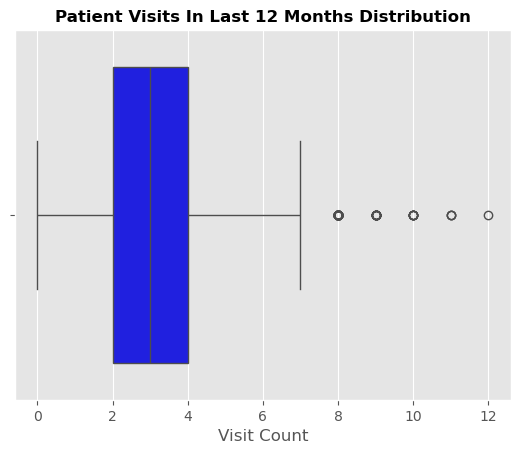

In [10]:
sns.boxplot(data=df, x='Prior_Visits_12m', color='blue')
plt.title("Patient Visits In Last 12 Months Distribution", fontsize=fontsize, fontweight=fontweight)
plt.xlabel("Visit Count")
plt.show()

In [11]:
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())
df.dropna(subset=['Provider_Specialty', 'Insurance_Type'], inplace=True)
print("Data Frame Shape After Cleaning:", df.shape, '|', "Data Frame Size After Cleaning:", df.size)
print(output_divider)
missing_data = df.isna().sum()
print("Confirm No More Missing Data:")
print(missing_data)

Data Frame Shape After Cleaning: (9315, 20) | Data Frame Size After Cleaning: 186300
Confirm No More Missing Data:
Provider_ID                              0
Claim_ID                                 0
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Claim_Submission_Date                    0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64


In [12]:
#Categorical Data Inspection

In [13]:
objects = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", objects)

Categorical Features: ['Provider_ID', 'Claim_ID', 'Patient_Gender', 'Diagnosis_Code', 'Insurance_Type', 'Claim_Submission_Date', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']


In [14]:
print("Providers:", df['Provider_ID'].unique().tolist())
print(output_divider)
print("Genders:", df['Patient_Gender'].unique().tolist())
print(output_divider)
print("Diagnosis Codes:", df['Diagnosis_Code'].unique().tolist())
print(output_divider)
print("Insurance Types:", df['Insurance_Type'].unique().tolist())
print(output_divider)
print("Provider Specialties:", df['Provider_Specialty'].unique().tolist())
print(output_divider)
print("Patient States:", df['Patient_State'].unique().tolist())
print(output_divider)
print("Claim Statuses:", df['Claim_Status'].unique().tolist())
print(output_divider)
print("Visit Types:", df['Visit_Type'].unique().tolist())

Providers: ['P0052', 'P0121', 'P0140', 'P0202', 'P0135', 'P0241', 'P0196', 'P0097', 'P0125', 'P0021', 'P0256', 'P0293', 'P0033', 'P0274', 'P0100', 'P0290', 'P0103', 'P0009', 'P0050', 'P0285', 'P0054', 'P0222', 'P0225', 'P0292', 'P0153', 'P0215', 'P0003', 'P0235', 'P0240', 'P0067', 'P0039', 'P0169', 'P0112', 'P0192', 'P0026', 'P0092', 'P0213', 'P0159', 'P0122', 'P0011', 'P0212', 'P0027', 'P0000', 'P0284', 'P0144', 'P0160', 'P0064', 'P0051', 'P0297', 'P0018', 'P0137', 'P0163', 'P0247', 'P0179', 'P0072', 'P0024', 'P0177', 'P0154', 'P0016', 'P0199', 'P0219', 'P0287', 'P0237', 'P0022', 'P0111', 'P0151', 'P0046', 'P0073', 'P0105', 'P0069', 'P0116', 'P0065', 'P0167', 'P0133', 'P0175', 'P0280', 'P0266', 'P0146', 'P0209', 'P0189', 'P0044', 'P0083', 'P0195', 'P0066', 'P0020', 'P0012', 'P0263', 'P0071', 'P0226', 'P0148', 'P0110', 'P0161', 'P0131', 'P0251', 'P0093', 'P0205', 'P0075', 'P0270', 'P0248', 'P0272', 'P0113', 'P0081', 'P0147', 'P0149', 'P0106', 'P0132', 'P0294', 'P0126', 'P0204', 'P0028'

In [15]:
comments = "No spelling, spacing, or capitalization inconsistencies need to be corrected."
print(comments)

No spelling, spacing, or capitalization inconsistencies need to be corrected.


In [16]:
#Data Type Conversions

In [17]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])
df['Claim_Year'] = df['Claim_Submission_Date'].dt.strftime('%Y')
df['Claim_Month'] = df['Claim_Submission_Date'].dt.strftime('%m')
df['Claim_Day'] = df['Claim_Submission_Date'].dt.strftime('%d')
df['Claim_Year'] = df['Claim_Year'].astype('int64')
df['Claim_Day'] = df['Claim_Day'].astype('int64')
df['Claim_Month'] = df['Claim_Month'].astype('int64')
df['Fraud_Status'] = df['Is_Fraud'].map({
    0: 'No',
    1: 'Yes'})
print("Confirm Data Type Conversations:", df.dtypes)
print(output_divider)
df.head()

Confirm Data Type Conversations: Provider_ID                                      object
Claim_ID                                         object
Patient_Age                                       int64
Patient_Gender                                   object
Diagnosis_Code                                   object
Procedure_Code                                    int64
Claim_Amount                                    float64
Approved_Amount                                 float64
Insurance_Type                                   object
Claim_Submission_Date                    datetime64[ns]
Days_Between_Service_and_Claim                    int64
Number_of_Claims_Per_Provider_Monthly             int64
Provider_Specialty                               object
Patient_State                                    object
Claim_Status                                     object
Is_Fraud                                          int64
Length_of_Stay                                    int64
Visit_Type     

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,...,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Year,Claim_Month,Claim_Day,Fraud_Status
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,...,Approved,0,0,Outpatient,1,2.0,2024,9,1,No
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,...,Pending,0,5,Inpatient,1,2.0,2022,9,5,No
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,...,Pending,0,5,Inpatient,1,3.0,2022,4,11,No
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,...,Approved,0,0,Emergency,0,5.0,2023,10,11,No
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,...,Approved,0,5,Inpatient,0,4.0,2023,9,5,No


In [18]:
#Part 2: Visualization EDA

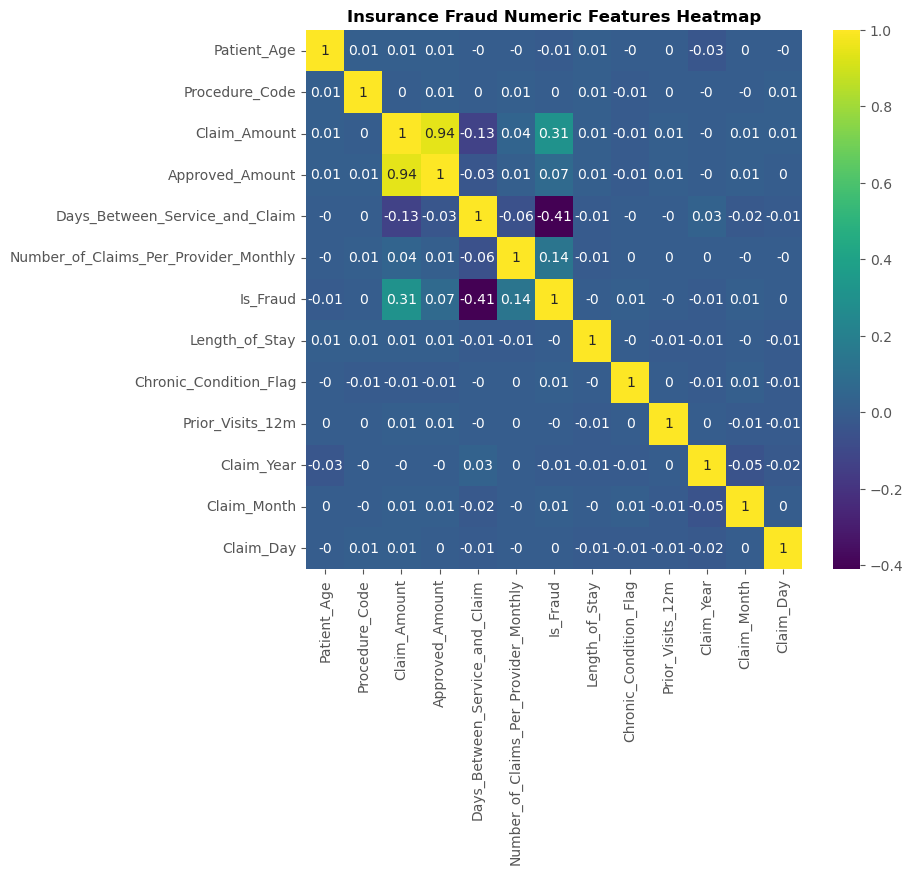

In [19]:
corr = df.select_dtypes(include=['int64', 'float64']).corr().round(2)
plt.figure(figsize=(8,7))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title("Insurance Fraud Numeric Features Heatmap", fontsize=fontsize, fontweight=fontweight)
plt.show()

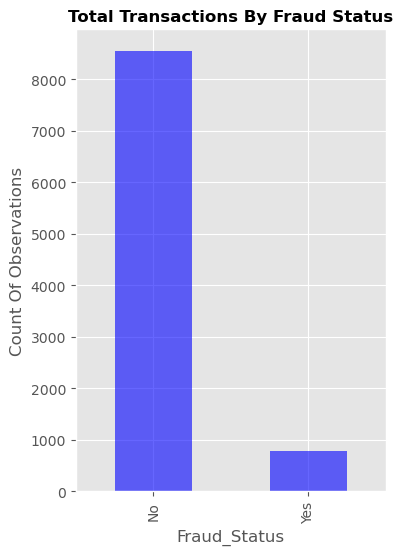

In [20]:
fraud_counts = df['Fraud_Status'].value_counts()
plt.figure(figsize=(4,6))
fraud_counts.plot(kind='bar', color='blue', alpha=0.6)
plt.title("Total Transactions By Fraud Status", fontweight=fontweight, fontsize=fontsize)
plt.ylabel("Count Of Observations")
plt.show()

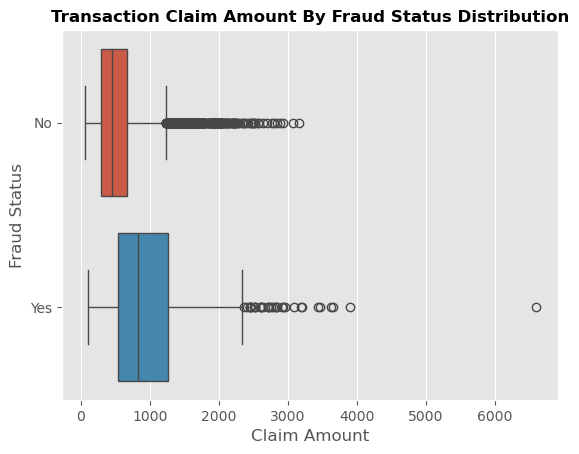

In [21]:
sns.boxplot(data=df,x='Claim_Amount', y='Fraud_Status', hue='Fraud_Status')
plt.title("Transaction Claim Amount By Fraud Status Distribution",
          fontweight=fontweight, fontsize=fontsize)
plt.xlabel("Claim Amount")
plt.ylabel("Fraud Status")
plt.show()

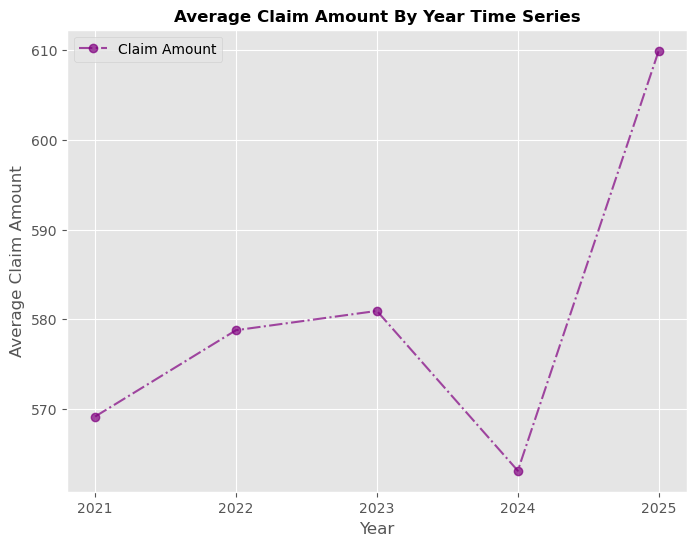

In [22]:
year_claim = df.groupby('Claim_Year')['Claim_Amount'].mean()
plt.figure(figsize=(8,6))
year_claim.plot(kind='line', marker='o', linestyle='dashdot', color='purple',
                alpha=0.7, label='Claim Amount')
plt.title("Average Claim Amount By Year Time Series", fontweight=fontweight, fontsize=fontsize)
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.xlabel("Year")
plt.ylabel("Average Claim Amount")
plt.legend(loc='best')
plt.show()

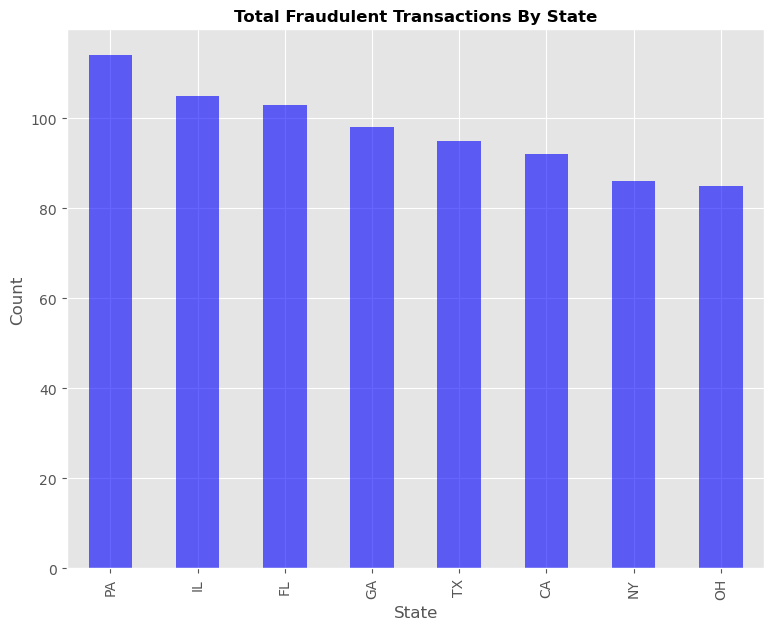

In [23]:
fraud_only = df.query("Fraud_Status == 'Yes'")
fraud_states = fraud_only.groupby("Patient_State")['Fraud_Status'].count().sort_values(ascending=False)
plt.figure(figsize=(9,7))
fraud_states.plot(kind='bar', color='blue', alpha=0.6)
plt.title("Total Fraudulent Transactions By State", 
          fontweight=fontweight, fontsize=fontsize)
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

In [24]:
#Part 3: Machine Learning

In [25]:
#3A: Data Preparation

In [26]:
print("Review Data Types and Header:")
print(df.dtypes)
print(output_divider)
df.head()

Review Data Types and Header:
Provider_ID                                      object
Claim_ID                                         object
Patient_Age                                       int64
Patient_Gender                                   object
Diagnosis_Code                                   object
Procedure_Code                                    int64
Claim_Amount                                    float64
Approved_Amount                                 float64
Insurance_Type                                   object
Claim_Submission_Date                    datetime64[ns]
Days_Between_Service_and_Claim                    int64
Number_of_Claims_Per_Provider_Monthly             int64
Provider_Specialty                               object
Patient_State                                    object
Claim_Status                                     object
Is_Fraud                                          int64
Length_of_Stay                                    int64
Visit_Type        

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,...,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Year,Claim_Month,Claim_Day,Fraud_Status
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,...,Approved,0,0,Outpatient,1,2.0,2024,9,1,No
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,...,Pending,0,5,Inpatient,1,2.0,2022,9,5,No
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,...,Pending,0,5,Inpatient,1,3.0,2022,4,11,No
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,...,Approved,0,0,Emergency,0,5.0,2023,10,11,No
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,...,Approved,0,5,Inpatient,0,4.0,2023,9,5,No


In [27]:
X = df.drop(columns=['Provider_ID', 'Claim_ID', 'Diagnosis_Code', 'Procedure_Code', 'Claim_Submission_Date',
                     'Is_Fraud', 'Fraud_Status'], axis=1)
y = df['Is_Fraud']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical Features:", categorical_features)
print(output_divider)
print("Numeric_Features:", numeric_features)

Categorical Features: ['Patient_Gender', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']
Numeric_Features: ['Patient_Age', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m', 'Claim_Year', 'Claim_Month', 'Claim_Day']


In [28]:
random_state = 42
cv = KFold(n_splits=5, shuffle = True, random_state=random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=random_state, test_size=0.2)

In [29]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

preprocessor = ColumnTransformer(transformers=[
    ('categorical', categorical_transformer, categorical_features),
    ('numeric', numeric_transformer, numeric_features)])

In [30]:
#3B: Random Forest Classifier Cross Validations

In [31]:
RF_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('Random_Forest', RandomForestClassifier(random_state=random_state,
                                              n_estimators=50, max_depth=10))])

In [32]:
RF_Untuned_CrossVal = cross_val_score(RF_Pipeline, X_train, y_train, cv=cv, scoring='f1')
RF_Untuned_CrossVal_Mean = RF_Untuned_CrossVal.mean()
print("Untuned Random Forest Cross Validation Scores:", RF_Untuned_CrossVal)
print(output_divider)
print("Untuned Random Forest Mean Cross Validation Score:", RF_Untuned_CrossVal_Mean)

Untuned Random Forest Cross Validation Scores: [0.77828054 0.78333333 0.75598086 0.76923077 0.77      ]
Untuned Random Forest Mean Cross Validation Score: 0.7713651013589093


In [33]:
#3C: Random Forest Classifier Hyperparameter Tuning

In [34]:
RF_Params = {'Random_Forest__n_estimators': [50, 75, 100],
           'Random_Forest__max_depth': [None, 5, 10]}
RF_Grid = GridSearchCV(RF_Pipeline, RF_Params, verbose=2, scoring='f1')
RF_Grid.fit(X_train, y_train)
print(output_divider)
print("Best Random Forest Parameters:", RF_Grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=50; total time=   0.9s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=50; total time=   1.0s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=50; total time=   1.0s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=50; total time=   1.0s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=50; total time=   1.0s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=75; total time=   1.4s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=75; total time=   1.4s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=75; total time=   1.5s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=75; total time=   1.5s
[CV] END Random_Forest__max_depth=None, Random_Forest__n_estimators=75; total time=   1.5s
[CV] END Random_Forest__max_de

In [35]:
RF_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('Random_Forest', RandomForestClassifier(random_state=random_state,
                                              n_estimators=75, max_depth=None))])

In [36]:
RF_Tuned_CrossVal = cross_val_score(RF_Pipeline, X_train, y_train, cv=cv, scoring='f1')
RF_Tuned_CrossVal_Mean = RF_Tuned_CrossVal.mean()
print("Tuned Random Forest Cross Validation Scores:", RF_Tuned_CrossVal)
print(output_divider)
print("Tuned Random Forest Mean Cross Validation Score:", RF_Tuned_CrossVal_Mean)

Tuned Random Forest Cross Validation Scores: [0.80888889 0.79352227 0.79069767 0.78817734 0.77669903]
Tuned Random Forest Mean Cross Validation Score: 0.7915970399083325


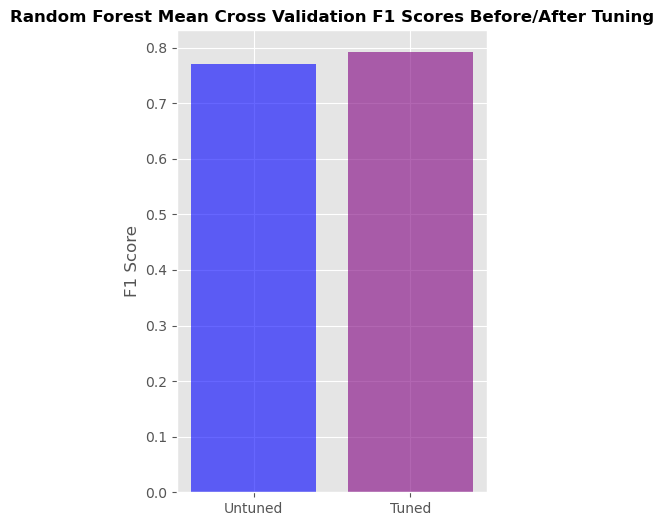

In [37]:
statuses = ['Untuned', 'Tuned']
scores = [RF_Untuned_CrossVal_Mean, RF_Tuned_CrossVal_Mean]
colors = ['blue', 'purple']
plt.figure(figsize=(4,6))
plt.bar(statuses, scores, color=colors, alpha=0.6)
plt.title("Random Forest Mean Cross Validation F1 Scores Before/After Tuning", 
          fontweight=fontweight, fontsize=fontsize)
plt.ylabel("F1 Score")
plt.show()

In [38]:
comments = "Random Forest parameter tuning resulted in a marginal F1 score increase."
print(comments)

Random Forest parameter tuning resulted in a marginal F1 score increase.


In [39]:
#3D: Gradient Boosting Classifier Cross Validations

In [40]:
GB_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('Gradient_Boosting', GradientBoostingClassifier(random_state=random_state,
                                             max_depth=5, n_estimators=50))])

In [41]:
GB_Untuned_CrossVal = cross_val_score(GB_Pipeline, X_train, y_train, cv=cv, scoring='f1')
GB_Untuned_CrossVal_Mean = GB_Untuned_CrossVal.mean()
print("Untuned Gradient Boosting Cross Validation Scores:", GB_Untuned_CrossVal)
print(output_divider)
print("Untuned Gradient Boosting Mean Cross Validation Score:", GB_Untuned_CrossVal_Mean)

Untuned Gradient Boosting Cross Validation Scores: [0.9218107  0.92883895 0.91150442 0.92237443 0.92035398]
Untuned Gradient Boosting Mean Cross Validation Score: 0.9209764974405458


In [42]:
#3E: Gradient Boosting Classifier Hyperparameter Tuning

In [43]:
GB_Params = {'Gradient_Boosting__n_estimators': [50, 75, 100],
           'Gradient_Boosting__max_depth': [None, 5, 10]}
GB_Grid = GridSearchCV(GB_Pipeline, GB_Params, verbose=2, scoring='f1')
GB_Grid.fit(X_train, y_train)
print(output_divider)
print("Best Gradient Boosting Parameters:", GB_Grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=50; total time=   3.4s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=50; total time=   3.6s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=50; total time=   3.0s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=50; total time=   3.3s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=50; total time=   3.8s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=75; total time=   4.9s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=75; total time=   5.4s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=75; total time=   4.4s
[CV] END Gradient_Boosting__max_depth=None, Gradient_Boosting__n_estimators=75; total time=   4.9s
[CV] END Gradient_Boosting__max_depth=None, Gradi

In [44]:
GB_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('Gradient_Boosting', GradientBoostingClassifier(random_state=random_state,
                                             max_depth=5, n_estimators=100))])

In [45]:
GB_Tuned_CrossVal = cross_val_score(GB_Pipeline, X_train, y_train, cv=cv, scoring='f1')
GB_Tuned_CrossVal_Mean = GB_Tuned_CrossVal.mean()
print("Tuned Gradient Boosting Cross Validation Scores:", GB_Tuned_CrossVal)
print(output_divider)
print("Tuned Gradient Boosting Mean Cross Validation Score:", GB_Tuned_CrossVal_Mean)

Tuned Gradient Boosting Cross Validation Scores: [0.93117409 0.94814815 0.91964286 0.9321267  0.94372294]
Tuned Gradient Boosting Mean Cross Validation Score: 0.9349629469830708


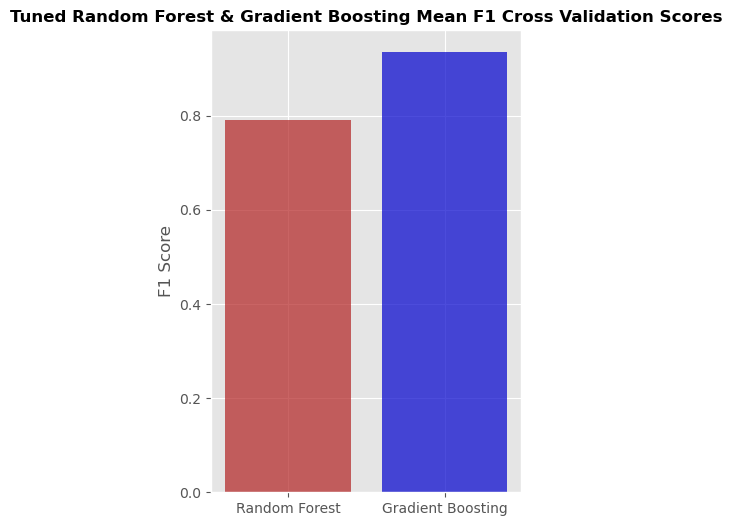

In [46]:
models = ['Random Forest', 'Gradient Boosting']
scores = [RF_Tuned_CrossVal_Mean, GB_Tuned_CrossVal_Mean]
colors = ['firebrick', 'mediumblue']
plt.figure(figsize=(4,6))
plt.bar(models, scores, color=colors, alpha=0.7)
plt.title("Tuned Random Forest & Gradient Boosting Mean F1 Cross Validation Scores",
        fontweight=fontweight, fontsize=fontsize)
plt.ylabel("F1 Score")
plt.show()

In [47]:
comments = """Gradient Boosting will be selected as the final model due to superior F1 cross validation 
scoring over Random Random Forest."""
print(comments)

Gradient Boosting will be selected as the final model due to superior F1 cross validation 
scoring over Random Random Forest.


In [48]:
#3F: Fit Final Model And Evaluate Classification Metrics

In [49]:
print("Fit Final Model:")
GB_Pipeline.fit(X_train, y_train)

Fit Final Model:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Gradient_Boosting', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [50]:
y_pred = GB_Pipeline.predict(X_test)
print("Gradient Boosting Classification Report:")
print(classification_report(y_pred, y_test))
print(output_divider)
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Gradient Boosting Confusion Matrix:", confusion_matrix)

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1727
           1       0.85      0.99      0.91       136

    accuracy                           0.99      1863
   macro avg       0.92      0.99      0.95      1863
weighted avg       0.99      0.99      0.99      1863

Gradient Boosting Confusion Matrix: [[1703    2]
 [  24  134]]


In [51]:
#3G: Gradient Boosting Classifier Feature Evaluation

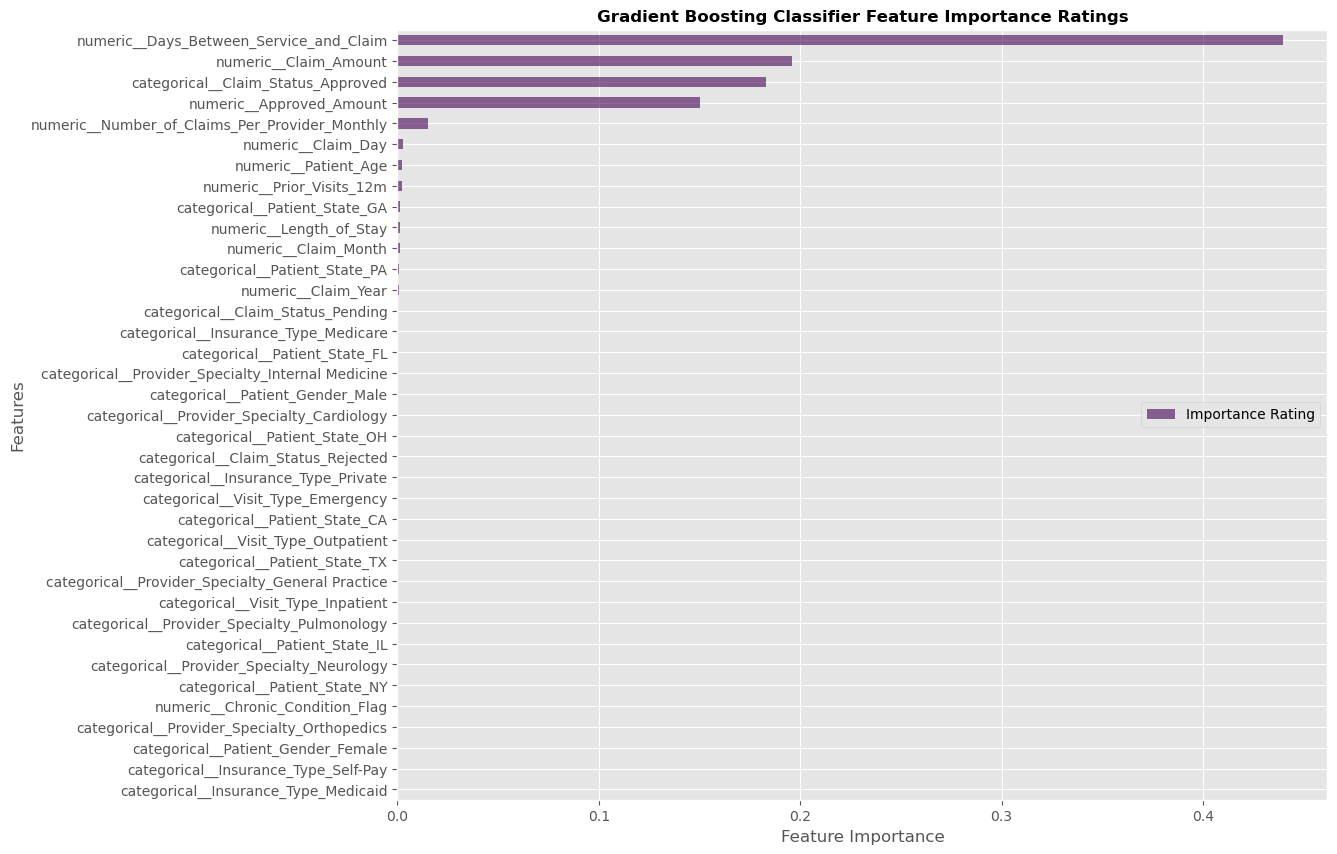

In [52]:
GB_Features = GB_Pipeline.named_steps['preprocessor'].get_feature_names_out()
GB_Values = GB_Pipeline.named_steps['Gradient_Boosting'].feature_importances_
Feature_Results = pd.Series(GB_Values, index=GB_Features).sort_values()
plt.figure(figsize=(12,10))
Feature_Results.plot(kind='barh', cmap='viridis', alpha=0.6, label="Importance Rating")
plt.title("Gradient Boosting Classifier Feature Importance Ratings",
          fontweight=fontweight, fontsize=fontsize)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.legend(loc='center right')
plt.show()

In [53]:
#End Of Notebook